<a href="https://colab.research.google.com/github/Mitu0601/SalesIQ-LLM-Powered-Business-Analytics-Engine/blob/main/01_eda_and_ml_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-Learn ──────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── XGBoost ───────────────────────────────────────────────────────────────────
# Install if needed: pip install xgboost
from xgboost import XGBRegressor

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

DATA_FILE   = 'CFL_External_Data_Pack_Phase1.xlsx'
ACTUAL_QTRS = ['FY23 Q2','FY23 Q3','FY23 Q4',
               'FY24 Q1','FY24 Q2','FY24 Q3','FY24 Q4',
               'FY25 Q1','FY25 Q2','FY25 Q3','FY25 Q4',
               'FY26 Q1']

print('✅ All libraries loaded.')
print(f'   NumPy {np.__version__} | Pandas {pd.__version__}')

✅ All libraries loaded.
   NumPy 2.0.2 | Pandas 2.2.2


---
## CRITERION 2 — Pandas: Data Cleaning & Manipulation [CO2 | 5 marks]

### 2.1 Load All Sheets

In [ ]:
DATA_FILE = '/content/CFL_External Data Pack_Phase1.xlsx' # Corrected path
xls = pd.ExcelFile(DATA_FILE)
print('Available sheets:', xls.sheet_names)

# Multi-row header → use row index 2 as header
raw      = pd.read_excel(DATA_FILE, sheet_name='Data Pack - Actual Bookings', header=2)
bd_raw   = pd.read_excel(DATA_FILE, sheet_name='Big Deal',   header=1)
scms_raw = pd.read_excel(DATA_FILE, sheet_name='SCMS',       header=2)
vms_raw  = pd.read_excel(DATA_FILE, sheet_name='VMS',        header=2)

print(f'\nMain sheet shape: {raw.shape}')
raw.head(3)

Available sheets: ['Glossary', 'Masked Product Insights ', 'Data Pack - Actual Bookings', 'Big Deal', 'SCMS', 'VMS']

Main sheet shape: (28, 19)


,2,WIRELESS ACCESS POINT WiFi6E (Internal Antenna) Indoor,Sustaining,30498,40505,61214,41932,59424,60073,66952,57131,78096,87843,71494,58318,68706,79000.0,66274.81571,79114.0
0,3,SWITCH Core 25G/100G Fiber,Sustaining,4680.0,4397.0,5065.0,4092.0,4573.0,5449.0,5801,4868,5659,5701,6784,6346,6984,6620.962605,6739.907617,7861.0
1,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927.0,8358.0,11681.0,10461.0,9704.0,11345.0,9946,8461,8436,9436,10338,8433,8173,9200.438118,10383.999801,9789.0
2,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349.0,67670.0,55237.0,53599.0,53108.0,51781.0,59560,53245,60281,53710,41524,43188,41873,35588.000000,44460.246720,49532.0


### 2.2 Select Columns, Type-Cast, Handle Missing Values

In [ ]:
# ── Select and rename columns ──────────────────────────────────────────────────
# The actual column names in `raw` are not 'Unnamed: X' or 'FYXX QX'.
# Instead, the first three columns are header-like and the subsequent 12 are quarterly data.
# We select these based on their current positional names.
initial_cols = raw.columns[:3].tolist()
quarter_cols = raw.columns[3 : 3 + len(ACTUAL_QTRS)].tolist()
all_selected_cols = initial_cols + quarter_cols

df = raw[all_selected_cols].copy()
df.columns = ['Rank', 'Product', 'Lifecycle'] + ACTUAL_QTRS

# ── Keep only the 30 forecast products ───────────────────────────────────────
df = df.dropna(subset=['Product']).head(30).reset_index(drop=True)

# ── Type casting ──────────────────────────────────────────────────────────────
df['Rank']      = df['Rank'].astype(int)
df['Lifecycle'] = df['Lifecycle'].astype('category')       # category dtype
df[ACTUAL_QTRS] = df[ACTUAL_QTRS].apply(pd.to_numeric, errors='coerce')

# ── Inspect missing values before fill ────────────────────────────────────────
print('Missing values per quarter (before fill):')
print(df[ACTUAL_QTRS].isnull().sum().to_frame('null_count').T)

# ── Fill missing values: forward-fill then back-fill per column ───────────────
# (compatible with all pandas versions — avoids deprecated method= argument)
for col in ACTUAL_QTRS:
    df[col] = df[col].ffill().bfill()

print('\nMissing values after fill:')
print(df[ACTUAL_QTRS].isnull().sum().to_frame('null_count').T)

print(f'\n✅ Clean dataset: {df.shape}  ({df.shape[0]} products × {df.shape[1]} columns)')
df.head()

Missing values per quarter (before fill):
            FY23 Q2  FY23 Q3  FY23 Q4  FY24 Q1  FY24 Q2  FY24 Q3  FY24 Q4  \
null_count        5        5        2        2        1        1        0   

            FY25 Q1  FY25 Q2  FY25 Q3  FY25 Q4  FY26 Q1  
null_count        0        0        0        0        0  

Missing values after fill:
            FY23 Q2  FY23 Q3  FY23 Q4  FY24 Q1  FY24 Q2  FY24 Q3  FY24 Q4  \
null_count        0        0        0        0        0        0        0   

            FY25 Q1  FY25 Q2  FY25 Q3  FY25 Q4  FY26 Q1  
null_count        0        0        0        0        0  

✅ Clean dataset: (28, 15)  (28 products × 15 columns)


,Rank,Product,Lifecycle,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1
0,3,SWITCH Core 25G/100G Fiber,Sustaining,4680.0,4397.0,5065.0,4092.0,4573.0,5449.0,5801,4868,5659,5701,6784,6346
1,4,SWITCH Enterprise 24-Port PoE+,Sustaining,10927.0,8358.0,11681.0,10461.0,9704.0,11345.0,9946,8461,8436,9436,10338,8433
2,5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,84349.0,67670.0,55237.0,53599.0,53108.0,51781.0,59560,53245,60281,53710,41524,43188
3,6,ROUTER Core Modular Chassis,NPI-Ramp,84349.0,67670.0,55237.0,53599.0,53108.0,51781.0,305,116,555,735,1226,705
4,7,SWITCH Enterprise 48-Port Fiber (Non-PoE),Sustaining,1714.0,1755.0,2466.0,3770.0,1646.0,1719.0,2929,2911,2196,2093,2513,3035


### 2.3 GroupBy, Pivot Table & Multi-Index

In [ ]:
# ── GroupBy: total & mean bookings per lifecycle stage ────────────────────────
lifecycle_summary = (
    df.groupby('Lifecycle', observed=True)[ACTUAL_QTRS]
      .agg(['sum', 'mean', 'std'])
      .round(0)
)
print('=== GroupBy — Lifecycle Aggregation ===')
print(lifecycle_summary.to_string())

# ── Pivot Table: mean units per Lifecycle × Quarter ───────────────────────────
df_melt_piv = df.melt(id_vars=['Lifecycle'], value_vars=ACTUAL_QTRS,
                       var_name='Quarter', value_name='Units')
pivot_tbl = pd.pivot_table(
    df_melt_piv,
    index='Lifecycle',
    columns='Quarter',
    values='Units',
    aggfunc='mean'
).round(0)
print('\n=== Pivot Table — Mean Units per Lifecycle per Quarter ===')
pivot_tbl

=== GroupBy — Lifecycle Aggregation ===
             FY23 Q2                     FY23 Q3                     FY23 Q4                     FY24 Q1                    FY24 Q2                    FY24 Q3                   FY24 Q4                  FY25 Q1                  FY25 Q2                  FY25 Q3                  FY25 Q4                 FY26 Q1                
                 sum     mean      std       sum     mean      std       sum     mean      std       sum     mean      std      sum     mean      std      sum     mean      std     sum    mean      std     sum    mean      std     sum    mean      std     sum    mean      std     sum    mean     std     sum    mean     std
Lifecycle                                                                                                                                                                                                                                                                                                             

Quarter,FY23 Q2,FY23 Q3,FY23 Q4,FY24 Q1,FY24 Q2,FY24 Q3,FY24 Q4,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1
Lifecycle,,,,,,,,,,,,
Decline,7186.0,9784.0,9695.0,6439.0,8809.0,8177.0,6418.0,8097.0,6684.0,5871.0,5243.0,4335.0
NPI-Ramp,84349.0,67670.0,55237.0,53599.0,53108.0,51781.0,305.0,116.0,555.0,735.0,1226.0,705.0
Sustaining,6510.0,5366.0,4883.0,4778.0,4557.0,4654.0,5324.0,4873.0,5444.0,5202.0,5056.0,4646.0


In [ ]:
# ── Multi-Index: set Lifecycle + Rank as hierarchical index ───────────────────
df_mi = df.set_index(['Lifecycle', 'Rank'])   # multi-index

# Cross-section: pull all 'Sustaining' products
sustaining = df_mi.xs('Sustaining', level='Lifecycle')
print(f'Sustaining products ({len(sustaining)}): mean FY26 Q1 = {sustaining["FY26 Q1"].mean():.0f} units')

# Stack/unstack for quarter-as-rows view
stacked = df_mi[ACTUAL_QTRS].stack().rename('Units').reset_index()
stacked.columns = ['Lifecycle','Rank','Quarter','Units']
print(f'\nStacked (long) shape: {stacked.shape}')
stacked.head(6)

Sustaining products (21): mean FY26 Q1 = 4646 units

Stacked (long) shape: (336, 4)


,Lifecycle,Rank,Quarter,Units
0,Sustaining,3,FY23 Q2,4680.0
1,Sustaining,3,FY23 Q3,4397.0
2,Sustaining,3,FY23 Q4,5065.0
3,Sustaining,3,FY24 Q1,4092.0
4,Sustaining,3,FY24 Q2,4573.0
5,Sustaining,3,FY24 Q3,5449.0


### 2.4 Melt, Merge & Long-Format Pipeline

In [ ]:
# ── Melt to long format ────────────────────────────────────────────────────────
df_long = df.melt(id_vars=['Rank','Product','Lifecycle'],
                  value_vars=ACTUAL_QTRS,
                  var_name='Quarter', value_name='Units')

qtr_order    = {q: i for i, q in enumerate(ACTUAL_QTRS)}
df_long['t'] = df_long['Quarter'].map(qtr_order)
df_long      = df_long.sort_values(['Rank','t']).reset_index(drop=True)

# ── Duplicate check & removal ─────────────────────────────────────────────────
before = len(df_long)
df_long = df_long.drop_duplicates(subset=['Rank','Quarter'])
print(f'Duplicates removed: {before - len(df_long)}')

# ── Quarter-level summary ─────────────────────────────────────────────────────
qtr_summary = (
    df_long
    .groupby('Quarter', sort=False)['Units']
    .agg(Total='sum', Mean='mean', Std='std')
    .round(0)
    .reindex(ACTUAL_QTRS)
)
print('\nQuarterly summary (all 30 products):')
qtr_summary

Duplicates removed: 0

Quarterly summary (all 30 products):


,Total,Mean,Std
Quarter,,,
FY23 Q2,264165.0,9434.0,22173.0
FY23 Q3,239065.0,8538.0,18634.0
FY23 Q4,215940.0,7712.0,15666.0
FY24 Q1,192570.0,6878.0,14343.0
FY24 Q2,201653.0,7202.0,15026.0
FY24 Q3,198568.0,7092.0,14226.0
FY24 Q4,150609.0,5379.0,11727.0
FY25 Q1,151037.0,5394.0,11030.0
FY25 Q2,154991.0,5535.0,11752.0


---
## CRITERION 1 — NumPy: Statistical Foundations [CO1 | 5 marks]

### 1.1 Sales Matrix & Vectorised Statistics (No Raw Loops)

In [ ]:
# ── Build NumPy 2-D sales matrix ──────────────────────────────────────────────
S = df[ACTUAL_QTRS].values.astype(float)   # shape (30, 12)
print(f'Sales matrix S: {S.shape}  →  30 products × 12 quarters\n')

# ── Vectorised per-product statistics (axis=1) — zero raw loops ───────────────
prod_mean   = np.mean(S,       axis=1)                              # (30,)
prod_std    = np.std(S,        axis=1)
prod_cv     = np.where(prod_mean > 0, prod_std / prod_mean, 0)     # coeff of variation
prod_p25    = np.percentile(S, 25, axis=1)
prod_median = np.median(S,         axis=1)
prod_p75    = np.percentile(S, 75, axis=1)
prod_min    = np.min(S,        axis=1)
prod_max    = np.max(S,        axis=1)
prod_iqr    = prod_p75 - prod_p25                                   # interquartile range

# ── Broadcasting: z-score normalisation (30×1 shape broadcast over 30×12) ────
mu     = prod_mean[:, np.newaxis]    # (30, 1)
sigma  = np.where(prod_std[:, np.newaxis] > 0, prod_std[:, np.newaxis], 1)
S_zscore = (S - mu) / sigma          # (30, 12) — fully vectorised

# ── Quarter-level stats (axis=0) ──────────────────────────────────────────────
qtr_total = np.sum(S,  axis=0)       # total booked per quarter
qtr_mean  = np.mean(S, axis=0)
qtr_std   = np.std(S,  axis=0)

# ── Percentage of total portfolio each product represents ─────────────────────
grand_total   = np.sum(S)            # scalar
prod_share_pct = np.sum(S, axis=1) / grand_total * 100  # broadcasting scalar

# ── Summary DataFrame ─────────────────────────────────────────────────────────
stats_df = pd.DataFrame({
    'Rank'      : df['Rank'].values,
    'Product'   : df['Product'].values,
    'Mean'      : prod_mean.round(0).astype(int),
    'Std'       : prod_std.round(0).astype(int),
    'CV%'       : (prod_cv * 100).round(1),
    'IQR'       : prod_iqr.astype(int),
    'P25'       : prod_p25.astype(int),
    'Median'    : prod_median.astype(int),
    'P75'       : prod_p75.astype(int),
    'Min'       : prod_min.astype(int),
    'Max'       : prod_max.astype(int),
    'Share%'    : prod_share_pct.round(2),
})
print('=== NumPy Per-Product Statistics — All 30 Products ===')
stats_df.set_index('Rank')

Sales matrix S: (28, 12)  →  30 products × 12 quarters

=== NumPy Per-Product Statistics — All 30 Products ===


,Product,Mean,Std,CV%,IQR,P25,Median,P75,Min,Max,Share%
Rank,,,,,,,,,,,
3,SWITCH Core 25G/100G Fiber,5285,779,14.7,1072,4653,5257,5726,4092,6784,2.91
4,SWITCH Enterprise 24-Port PoE+,9794,1143,11.7,2122,8454,9825,10577,8358,11681,5.40
5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,56438,10753,19.1,6964,52776,53654,59740,41524,84349,31.11
6,ROUTER Core Modular Chassis,30782,31294,101.7,53341,667,26503,54008,116,84349,16.97
7,SWITCH Enterprise 48-Port Fiber (Non-PoE),2396,639,26.7,1169,1746,2331,2915,1646,3770,1.32
8,SWITCH Enterprise 25G Fiber,2626,549,20.9,832,2177,2586,3009,1979,3832,1.45
9,SWITCH Enterprise 24-Port UPOE,2811,813,28.9,1134,2200,2776,3335,1517,4614,1.55
10,ROUTER Enterprise Edge 10G/40G,498,125,25.1,102,427,498,530,352,858,0.27
11,SECURITY FIREWALL Next-Generation_2,254,77,30.2,52,218,246,270,151,444,0.14


### 1.2 Correlation Matrix & Trend Slopes (np.corrcoef, np.linalg.lstsq)

In [ ]:
# ── Inter-product correlation (corrcoef on rows = products) ───────────────────
C = np.corrcoef(S)                   # (28, 28) in this case
print(f'Correlation matrix shape: {C.shape}\n')

# Top 5 most correlated pairs (upper triangle)
# Use df.shape[0] instead of hardcoded 30
num_products = df.shape[0]
iu  = np.triu_indices(num_products, k=1)
cv  = C[iu]
top = np.argsort(cv)[::-1][:5]
print('Top 5 correlated product pairs:')
for idx in top:
    i, j = iu[0][idx], iu[1][idx]
    print(f'  r={cv[idx]:.3f}  |  #{i+1} {df.Product.iloc[i][:30]}  ↔  #{j+1} {df.Product.iloc[j][:30]}')

# ── OLS trend slope per product via np.linalg.lstsq ─────────────────────────
t = np.arange(12)
A = np.vstack([t, np.ones(12)]).T     # design matrix (12, 2)
slopes = np.array([
    np.linalg.lstsq(A, S[i], rcond=None)[0][0]
    for i in range(num_products) # Use num_products here as well
])
stats_df['Slope'] = slopes.round(1)
print('\nProducts with strongest upward trend (slope = units/quarter):')
print(stats_df.nlargest(5,'Slope')[['Rank','Product','Slope']].to_string(index=False))

Correlation matrix shape: (28, 28)

Top 5 correlated product pairs:
  r=0.937  |  #6 SWITCH Enterprise 25G Fiber  ↔  #12 WIRELESS ACCESS POINT WiFi6E (
  r=0.914  |  #12 WIRELESS ACCESS POINT WiFi6E (  ↔  #25 SWITCH Industrial Managed
  r=0.890  |  #6 SWITCH Enterprise 25G Fiber  ↔  #24 SWITCH Industrial 8-Port PoE C
  r=0.876  |  #18 SWITCH Data Center 100G Spine  ↔  #25 SWITCH Industrial Managed
  r=0.874  |  #12 WIRELESS ACCESS POINT WiFi6E (  ↔  #19 SWITCH Core 100G/400G Fiber

Products with strongest upward trend (slope = units/quarter):
 Rank                                                 Product  Slope
   14 WIRELESS ACCESS POINT WiFi6E (External Antenna) Outdoor  626.6
   27                               SWITCH Industrial Managed  204.0
    3                              SWITCH Core 25G/100G Fiber  186.5
    8                             SWITCH Enterprise 25G Fiber  135.4
   17                  SWITCH Enterprise 24-Port PoE+ Compact  120.4


---
## CRITERION 3 — Advanced EDA: Feature Engineering & Insight [CO3 | 5 marks]

### 3.1 Engineer 9 Features per Product

In [ ]:
feat_rows = []

for _, row in df.iterrows():
    vals = row[ACTUAL_QTRS].values.astype(float)

    # 1. QoQ growth rates (vectorised np.diff)
    qoq = np.diff(vals) / np.where(vals[:-1] > 0, vals[:-1], 1)

    # 2. Rolling 4-quarter moving average (np.convolve — no Python loop)
    roll4 = np.convolve(vals, np.ones(4)/4, mode='valid')   # length 9

    # 3. Lag features
    lag1, lag2, lag4 = vals[-1], vals[-2], vals[-4]

    # 4. YoY growth (FY26 Q1 vs FY25 Q1)
    yoy = (vals[-1] - vals[-5]) / (vals[-5] + 1)

    # 5. Trend slope (lstsq)
    t_arr = np.arange(len(vals))
    A     = np.vstack([t_arr, np.ones(len(t_arr))]).T
    slope, intercept = np.linalg.lstsq(A, vals, rcond=None)[0]

    # 6. Recent momentum: last 2 qtrs mean vs first 2 qtrs mean
    momentum = np.mean(vals[-2:]) / (np.mean(vals[:2]) + 1)

    # 7. Volatility: std of last 4 quarters
    vol4 = np.std(vals[-4:])

    # 8. Ratio: current vs rolling 4-qtr mean (overperformance signal)
    ratio = vals[-1] / (roll4[-1] + 1)

    feat_rows.append({
        'Rank'       : int(row['Rank']),
        'Product'    : row['Product'],
        'Lifecycle'  : str(row['Lifecycle']),
        'mean_qoq'   : round(float(np.mean(qoq)),   4),
        'std_qoq'    : round(float(np.std(qoq)),    4),
        'roll4_last' : round(float(roll4[-1]),       1),
        'lag1'       : int(lag1),
        'lag2'       : int(lag2),
        'lag4'       : int(lag4),
        'yoy_growth' : round(float(yoy),            4),
        'slope'      : round(float(slope),          2),
        'momentum'   : round(float(momentum),       4),
        'vol4'       : round(float(vol4),           1),
        'roll_ratio' : round(float(ratio),          4),
    })

features = pd.DataFrame(feat_rows)
print(f'Feature matrix: {features.shape}  — 9 derived features for all 30 products')
features.set_index('Rank')

Feature matrix: (28, 14)  — 9 derived features for all 30 products


,Product,Lifecycle,mean_qoq,std_qoq,roll4_last,lag1,lag2,lag4,yoy_growth,slope,momentum,vol4,roll_ratio
Rank,,,,,,,,,,,,,
3,SWITCH Core 25G/100G Fiber,Sustaining,0.0370,0.1334,6122.5,6346,6784,5659,0.3036,186.48,1.4462,469.0,1.0363
4,SWITCH Enterprise 24-Port PoE+,Sustaining,-0.0083,0.1789,9160.8,8433,10338,8436,-0.0033,-141.90,0.9732,793.2,0.9205
5,WIRELESS ACCESS POINT WiFi6 (Internal Antenna)...,Sustaining,-0.0513,0.1212,49675.8,43188,41524,60281,-0.1889,-2297.81,0.5572,7702.1,0.8694
6,ROUTER Core Modular Chassis,NPI-Ramp,0.2084,1.2069,805.2,705,1226,555,5.0342,-8305.13,0.0127,252.3,0.8744
7,SWITCH Enterprise 48-Port Fiber (Non-PoE),Sustaining,0.1139,0.3388,2459.2,3035,2513,2196,0.0426,55.51,1.5984,366.7,1.2336
8,SWITCH Enterprise 25G Fiber,Sustaining,0.0596,0.1980,3212.8,3136,3832,3018,0.1399,135.44,1.7565,370.2,0.9758
9,SWITCH Enterprise 24-Port UPOE,Sustaining,0.0861,0.3979,2683.5,3302,2963,2309,-0.0941,-32.23,0.9944,467.7,1.2300
10,ROUTER Enterprise Edge 10G/40G,Decline,0.0545,0.2349,616.2,530,532,545,0.0536,23.24,1.2749,139.7,0.8586
11,SECURITY FIREWALL Next-Generation_2,Sustaining,0.1349,0.4059,281.5,252,332,235,0.5333,3.17,1.4209,39.5,0.8920


### 3.2 Time-Series Decomposition: Trend + Residual (Top-5 Products)

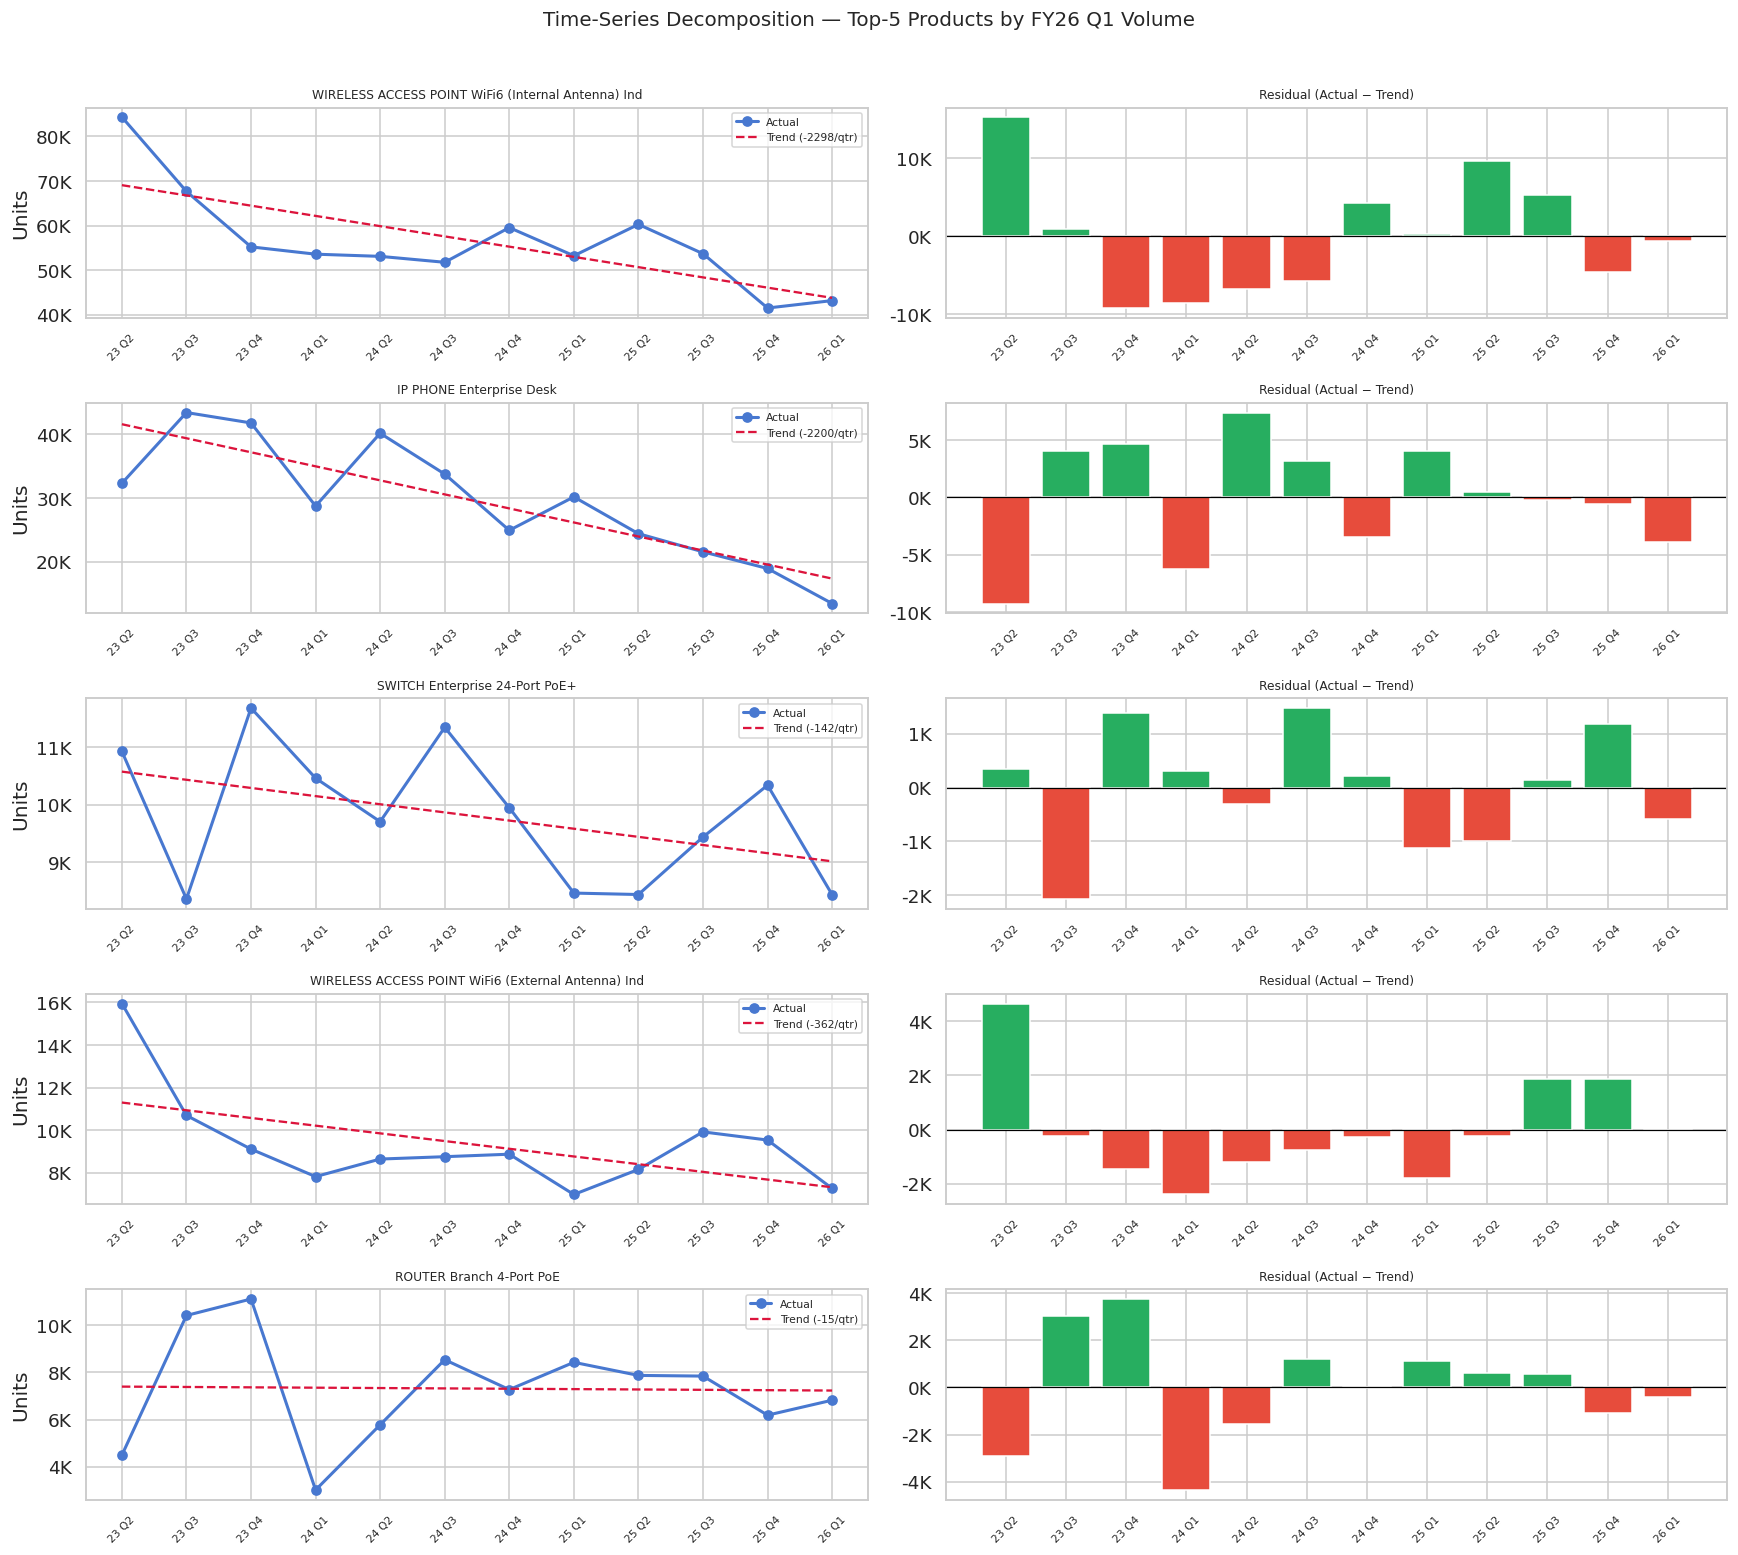

✅ Saved decomposition_top5.png


In [ ]:
TOP5    = df.nlargest(5, 'FY26 Q1')['Product'].tolist()
x_ticks = [q.replace('FY','') for q in ACTUAL_QTRS]

fig, axes = plt.subplots(5, 2, figsize=(16, 14))
fig.suptitle('Time-Series Decomposition — Top-5 Products by FY26 Q1 Volume',
             fontsize=13, y=1.01)

for idx, prod in enumerate(TOP5):
    vals = df.loc[df.Product == prod, ACTUAL_QTRS].values.flatten().astype(float)
    t    = np.arange(len(vals))
    A    = np.vstack([t, np.ones(len(t))]).T
    slope, intercept = np.linalg.lstsq(A, vals, rcond=None)[0]
    trend    = slope * t + intercept
    residual = vals - trend

    ax1 = axes[idx, 0]
    ax1.plot(x_ticks, vals,  marker='o', linewidth=2, label='Actual')
    ax1.plot(x_ticks, trend, linestyle='--', color='crimson',
             label=f'Trend ({slope:+.0f}/qtr)')
    ax1.set_title(prod[:50], fontsize=8)
    ax1.set_ylabel('Units')
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    ax1.legend(fontsize=7)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

    ax2 = axes[idx, 1]
    colors = ['#27ae60' if r >= 0 else '#e74c3c' for r in residual]
    ax2.bar(x_ticks, residual, color=colors)
    ax2.axhline(0, color='black', linewidth=0.8)
    ax2.set_title('Residual (Actual − Trend)', fontsize=8)
    ax2.tick_params(axis='x', rotation=45, labelsize=7)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig('decomposition_top5.png', bbox_inches='tight')
plt.show()
print('✅ Saved decomposition_top5.png')

### 3.3 Rolling Windows & Lag Correlation

In [ ]:
# ── Pandas rolling mean: 4-quarter window for all 30 products ─────────────────
# Transpose so time is the index, then rolling applies across quarters
df_ts      = df.set_index('Product')[ACTUAL_QTRS].T
df_roll4   = df_ts.rolling(window=4, min_periods=2).mean().T

print('Rolling 4-qtr mean — last 5 quarters:')
df_roll4[['FY25 Q1','FY25 Q2','FY25 Q3','FY25 Q4','FY26 Q1']].round(0).astype('Int64')

Rolling 4-qtr mean — last 5 quarters:


,FY25 Q1,FY25 Q2,FY25 Q3,FY25 Q4,FY26 Q1
Product,,,,,
SWITCH Core 25G/100G Fiber,5173,5444,5507,5753,6122
SWITCH Enterprise 24-Port PoE+,9864,9547,9070,9168,9161
WIRELESS ACCESS POINT WiFi6 (Internal Antenna) Indoor,54424,56217,56699,52190,49676
ROUTER Core Modular Chassis,26328,13189,428,658,805
SWITCH Enterprise 48-Port Fiber (Non-PoE),2301,2439,2532,2428,2459
SWITCH Enterprise 25G Fiber,2501,2698,2910,3116,3213
SWITCH Enterprise 24-Port UPOE,2350,2548,2582,2769,2684
ROUTER Enterprise Edge 10G/40G,473,515,606,610,616
SECURITY FIREWALL Next-Generation_2,224,222,241,260,282


---
## CRITERION 4 — Visualization [CO4 | 5 marks]

### 4.1 Small Multiples — All 30 Products with Trend Lines (Matplotlib)

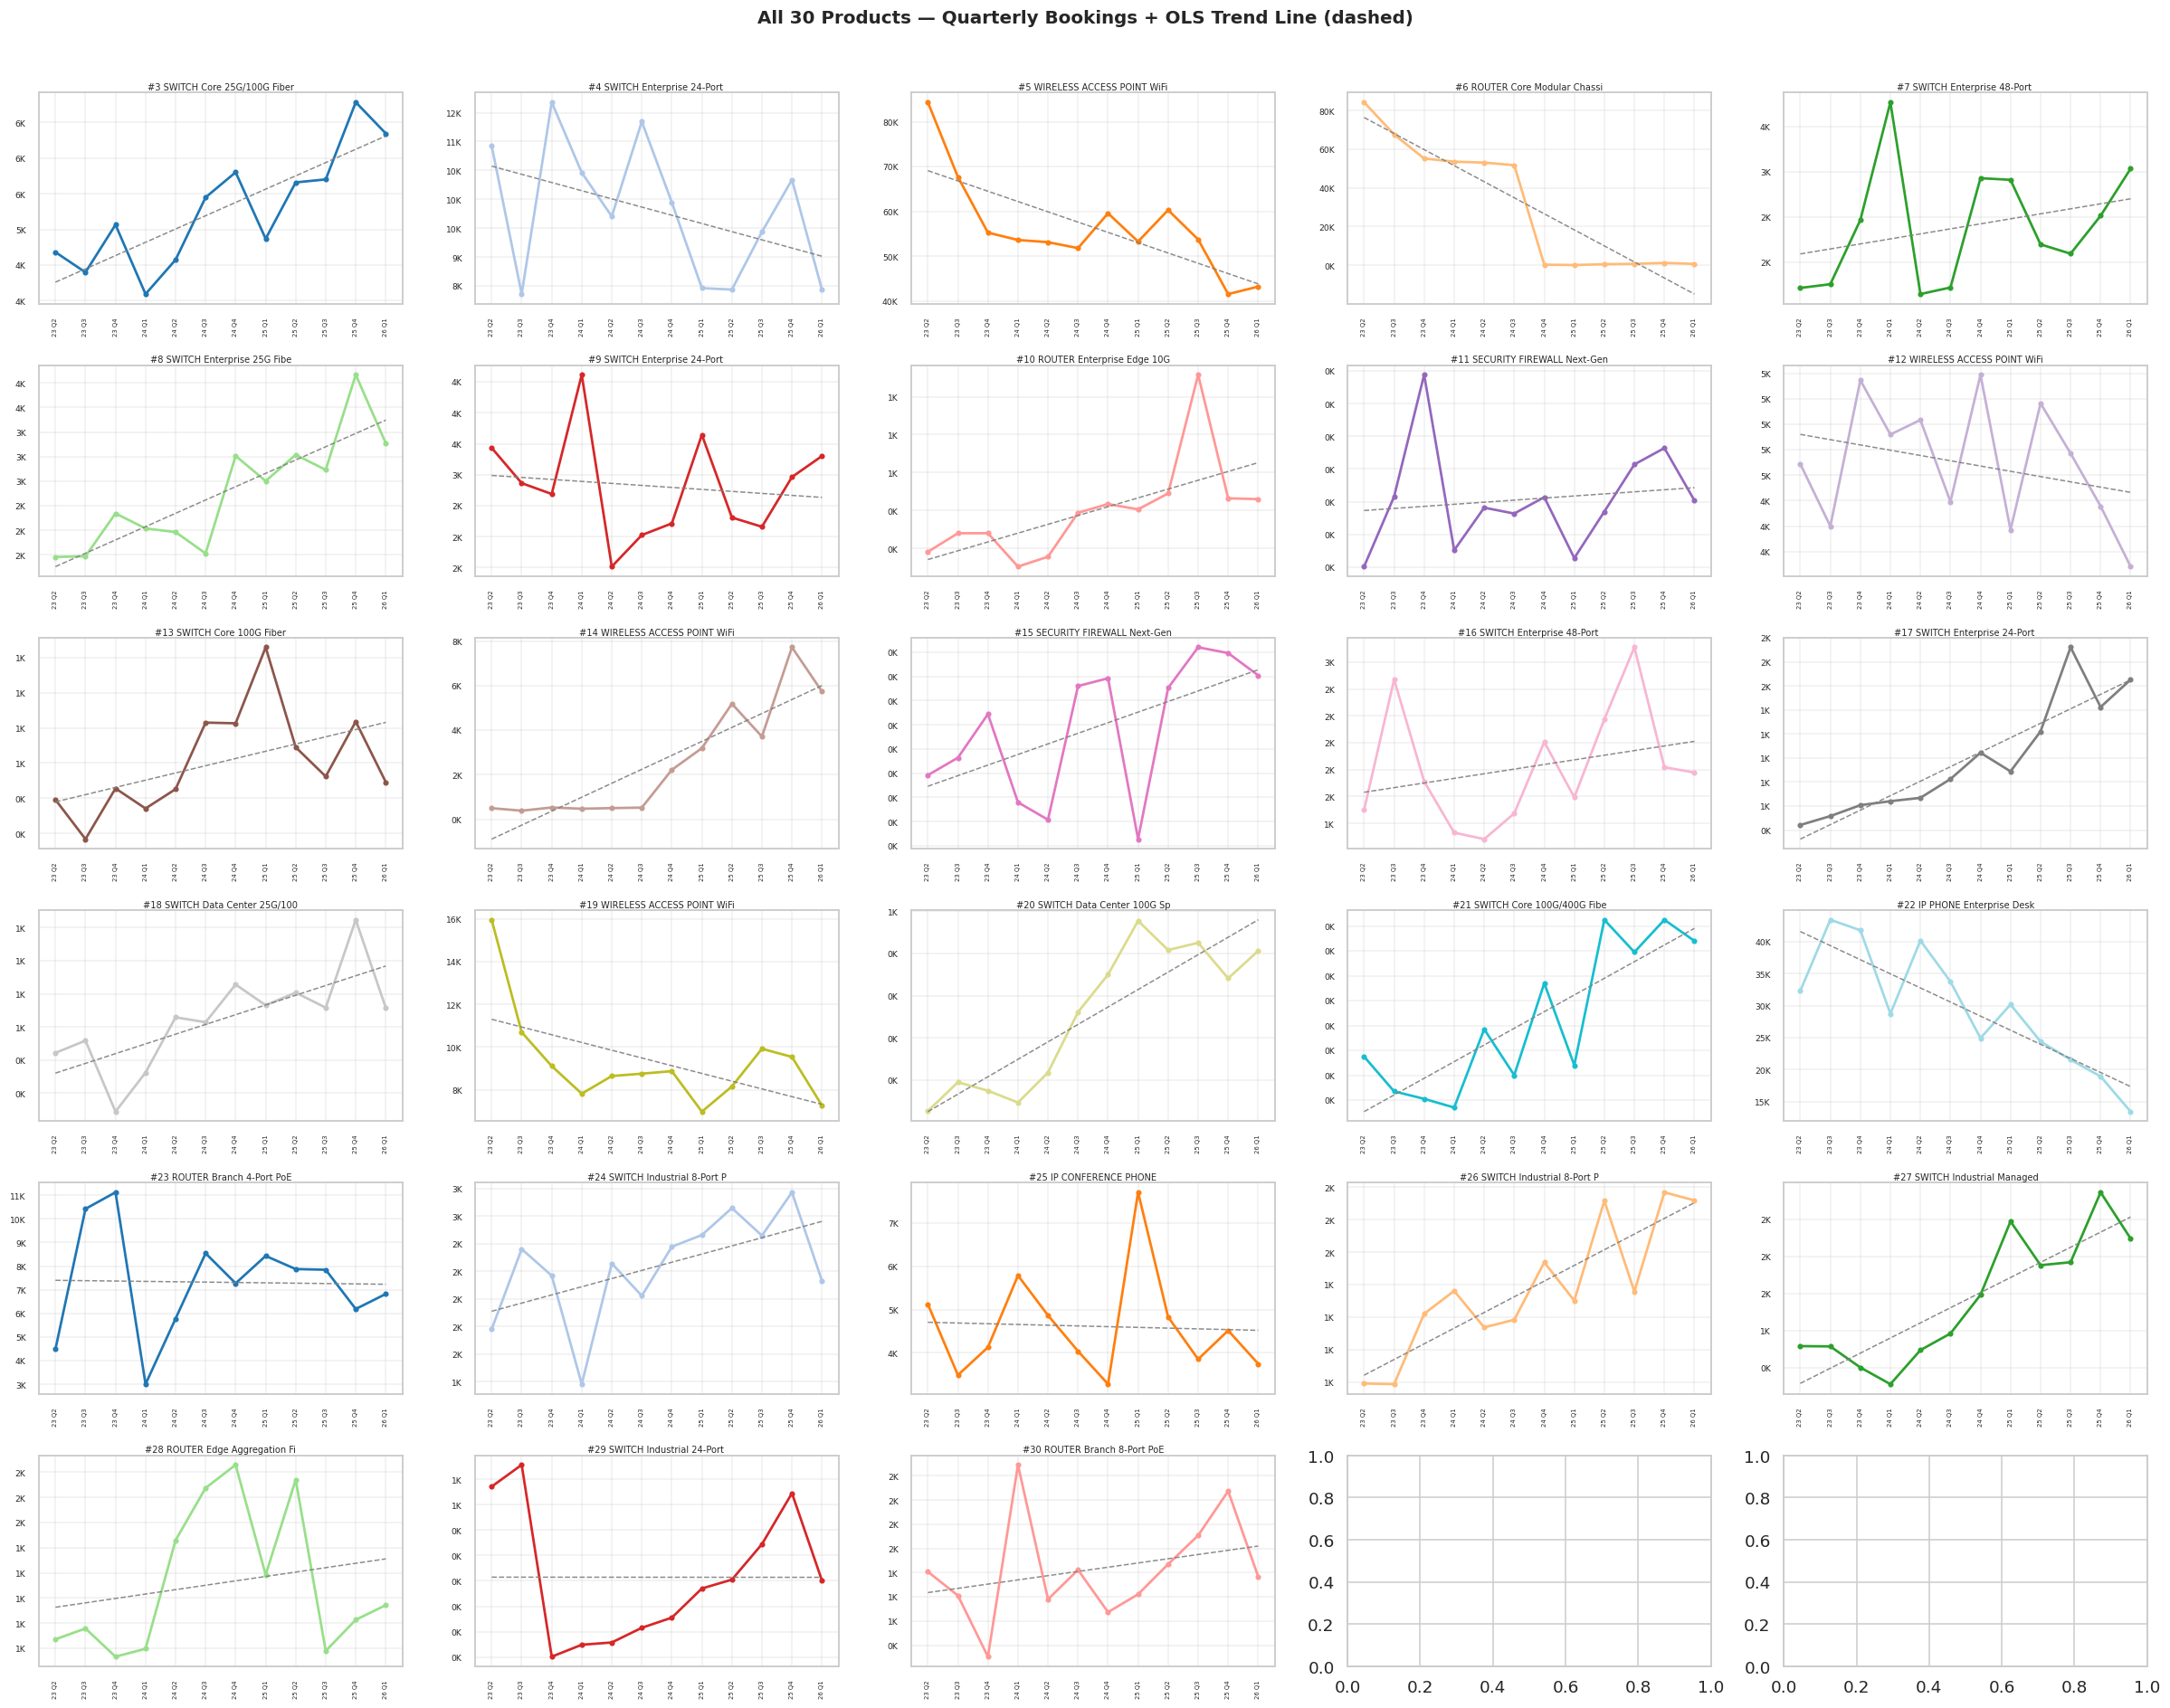

✅ Saved all30_trends.png


In [ ]:
fig, axes = plt.subplots(6, 5, figsize=(22, 17))
axes      = axes.flatten()
palette   = sns.color_palette('tab20', 30)

for i, (_, row) in enumerate(df.iterrows()):
    ax   = axes[i]
    vals = row[ACTUAL_QTRS].values.astype(float)
    t    = np.arange(len(vals))
    A    = np.vstack([t, np.ones(len(t))]).T
    slope, intercept = np.linalg.lstsq(A, vals, rcond=None)[0]

    ax.plot(t, vals, marker='o', markersize=3, linewidth=1.8, color=palette[i])
    ax.plot(t, slope*t + intercept, linestyle='--', color='gray',
            linewidth=1, alpha=0.9)
    ax.set_title(f'#{row["Rank"]} {row["Product"][:26]}', fontsize=6.5, pad=2)
    ax.set_xticks(t)
    ax.set_xticklabels([q.replace('FY','') for q in ACTUAL_QTRS],
                       rotation=90, fontsize=4.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))
    ax.tick_params(axis='y', labelsize=6)
    ax.grid(True, alpha=0.3)

fig.suptitle('All 30 Products — Quarterly Bookings + OLS Trend Line (dashed)',
             fontsize=13, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('all30_trends.png', bbox_inches='tight')
plt.show()
print('✅ Saved all30_trends.png')

### 4.2 Z-Score Heatmap (Seaborn)

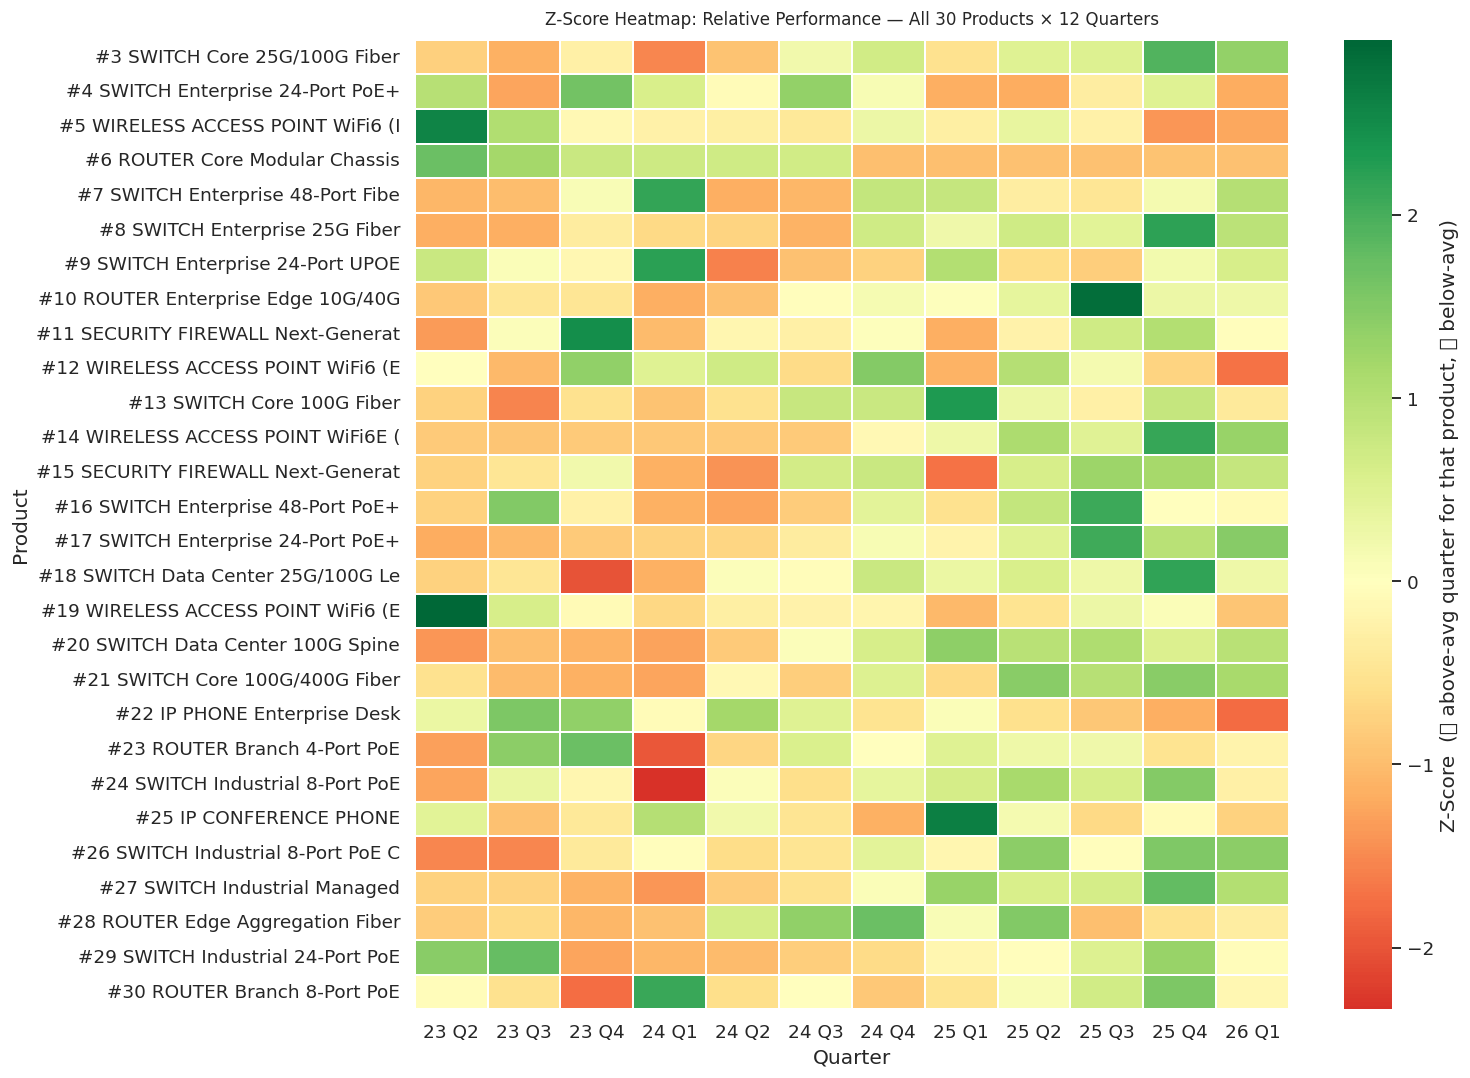

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

labels_y = [f'#{r} {p[:30]}' for r, p in zip(df['Rank'], df['Product'])]
labels_x = [q.replace('FY','') for q in ACTUAL_QTRS]

sns.heatmap(
    pd.DataFrame(S_zscore, index=labels_y, columns=labels_x),
    cmap='RdYlGn', center=0, linewidths=0.3, annot=False,
    cbar_kws={'label': 'Z-Score  (🟢 above-avg quarter for that product, 🔴 below-avg)'},
    ax=ax
)
ax.set_title('Z-Score Heatmap: Relative Performance — All 30 Products × 12 Quarters',
             fontsize=11, pad=10)
ax.set_xlabel('Quarter')
ax.set_ylabel('Product')
plt.tight_layout()
plt.savefig('zscore_heatmap.png', bbox_inches='tight')
plt.show()

### 4.3 Distribution Plots — Violin + Box (Seaborn)

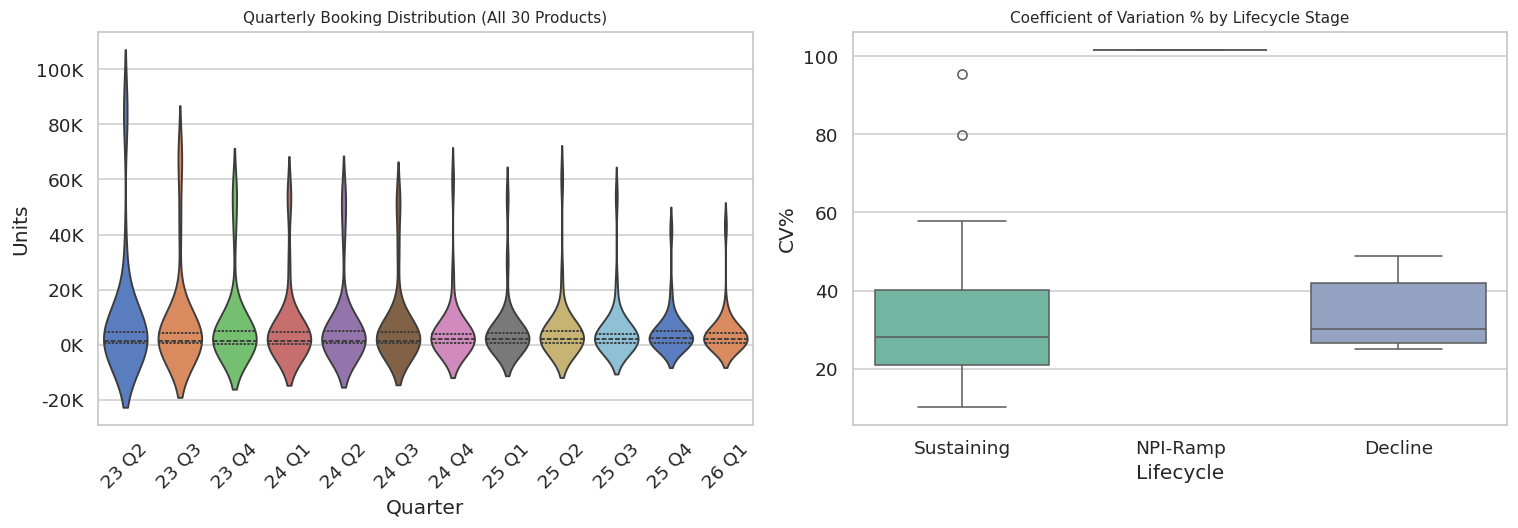

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin: quarterly booking spread
df_vis          = df_long.copy()
df_vis['Q_short'] = df_vis['Quarter'].str.replace('FY','')

sns.violinplot(data=df_vis, x='Q_short', y='Units',
               ax=axes[0], inner='quartile', palette='muted',
               density_norm='width')
axes[0].set_title('Quarterly Booking Distribution (All 30 Products)', fontsize=10)
axes[0].set_xlabel('Quarter')
axes[0].set_ylabel('Units')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1e3:.0f}K'))

# Box: CV% by lifecycle stage
stats_df['Lifecycle'] = df['Lifecycle'].astype(str).values
sns.boxplot(data=stats_df, x='Lifecycle', y='CV%',
            ax=axes[1], palette='Set2')
axes[1].set_title('Coefficient of Variation % by Lifecycle Stage', fontsize=10)
axes[1].set_xlabel('Lifecycle')
axes[1].set_ylabel('CV%')

plt.tight_layout()
plt.savefig('distribution_plots.png', bbox_inches='tight')
plt.show()

### 4.4 Comparative Horizontal Bar Chart (Matplotlib)

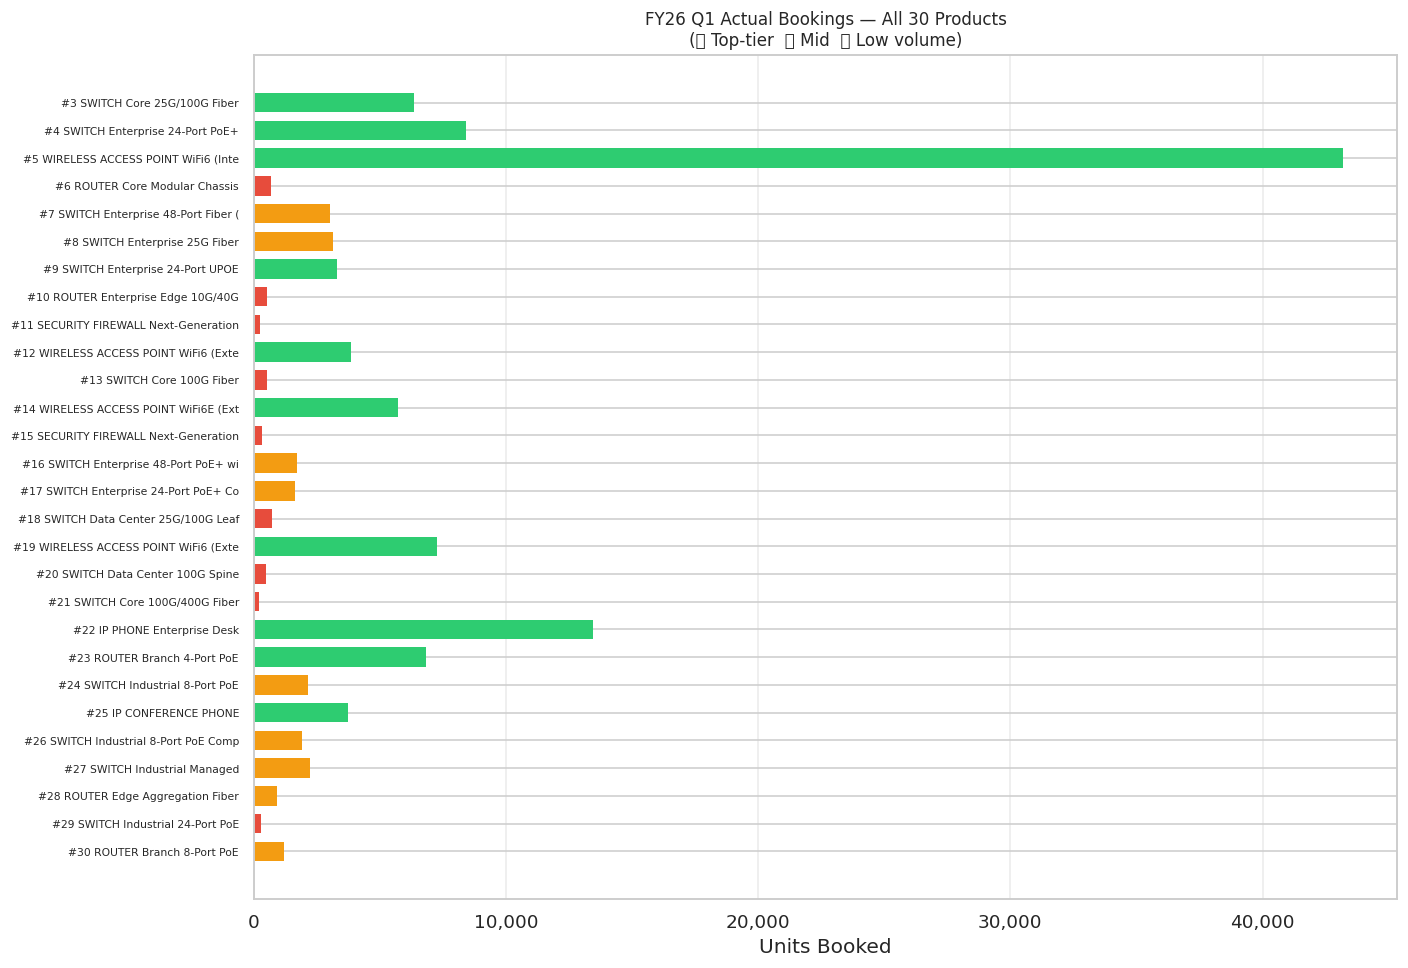

In [ ]:
fig, ax = plt.subplots(figsize=(13, 9))

y_pos  = np.arange(df.shape[0]) # Changed 30 to df.shape[0] to match number of products
labels = [f'#{r} {p[:33]}' for r, p in zip(df['Rank'], df['Product'])]
values = df['FY26 Q1'].values

q33, q66    = np.percentile(values, 33), np.percentile(values, 66)
bar_colors  = ['#2ecc71' if v >= q66 else ('#f39c12' if v >= q33 else '#e74c3c')
               for v in values]

ax.barh(y_pos, values, color=bar_colors, edgecolor='none', height=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Units Booked')
ax.set_title('FY26 Q1 Actual Bookings — All 30 Products\n'
             '(🟢 Top-tier  🟠 Mid  🔴 Low volume)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('fy26q1_bar.png', bbox_inches='tight')
plt.show()

### 4.5 Feature Correlation Heatmap (Seaborn)

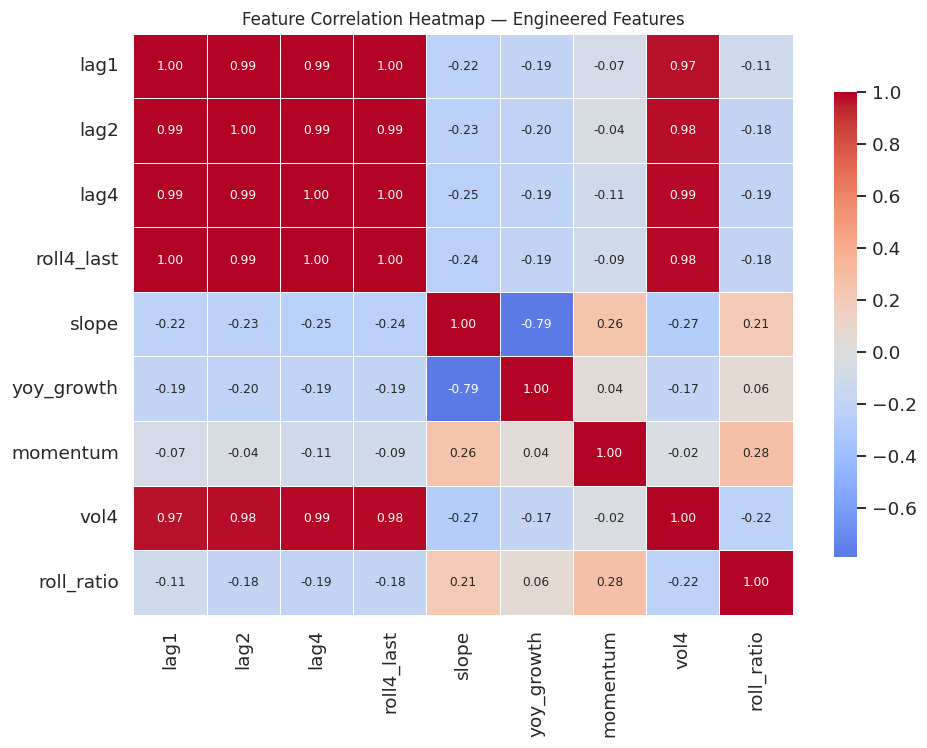

In [ ]:
feat_cols = ['lag1','lag2','lag4','roll4_last','slope','yoy_growth','momentum','vol4','roll_ratio']
fig, ax   = plt.subplots(figsize=(9, 7))
corr      = features[feat_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap — Engineered Features', fontsize=11)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight')
plt.show()

---
## CRITERION 5 — ML Forecasting & Model Validation [CO5 | 5 marks]
### Architecture: **Random Forest → XGBoost Residual Correction → Ridge Meta-Learner**

### 5.1 Build Supervised Feature Matrix (Walk-Forward)

In [ ]:
# Each product contributes (12-4) = 8 training samples
# Total: 240 supervised samples across 30 products

X_rows, y_rows = [], []

for _, row in df.iterrows():
    vals  = row[ACTUAL_QTRS].values.astype(float)
    t_arr = np.arange(len(vals))
    A     = np.vstack([t_arr, np.ones(len(t_arr))]).T
    slope = np.linalg.lstsq(A, vals, rcond=None)[0][0]

    for i in range(4, len(vals)):
        X_rows.append([
            vals[i-1],                                    # lag1
            vals[i-2],                                    # lag2
            vals[i-3],                                    # lag3
            vals[i-4],                                    # lag4
            np.mean(vals[i-4:i]),                         # rolling 4-qtr mean
            np.std(vals[i-4:i]),                          # rolling 4-qtr std (volatility)
            (vals[i-1] - vals[i-4]) / (vals[i-4] + 1),  # approx YoY growth
            i,                                            # time index
            slope,                                        # product trend slope
            np.mean(vals[i-2:i]),                         # 2-qtr mean
            vals[i-1] / (np.mean(vals[i-4:i-1]) + 1),   # ratio vs recent avg
        ])
        y_rows.append(vals[i])

X          = np.array(X_rows)   # (240, 11)
y          = np.array(y_rows)   # (240,)
FEAT_NAMES = ['lag1','lag2','lag3','lag4','roll4_mean','roll4_std',
              'yoy_growth','t_idx','trend_slope','roll2_mean','roll_ratio']

print(f'Feature matrix X : {X.shape}  ({len(FEAT_NAMES)} features)')
print(f'Target vector  y : {y.shape}')
print(f'Features: {FEAT_NAMES}')

Feature matrix X : (224, 11)  (11 features)
Target vector  y : (224,)
Features: ['lag1', 'lag2', 'lag3', 'lag4', 'roll4_mean', 'roll4_std', 'yoy_growth', 't_idx', 'trend_slope', 'roll2_mean', 'roll_ratio']


### 5.2 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples')

Train: 179 samples  |  Test: 45 samples


### 5.3 Stage 1 — Random Forest (Primary Model)

In [ ]:
rf = RandomForestRegressor(
    n_estimators  = 500,
    max_depth     = 8,
    min_samples_leaf = 1,
    max_features  = 'sqrt',
    random_state  = 42,
    n_jobs        = -1
)
rf.fit(X_train, y_train)

rf_pred_train = rf.predict(X_train)
rf_pred_test  = rf.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred_test))
rf_r2   = r2_score(y_test, rf_pred_test)

print('=== Stage 1: Random Forest ===')
print(f'  MAE  = {rf_mae:>8.0f} units')
print(f'  RMSE = {rf_rmse:>8.0f} units')
print(f'  R²   = {rf_r2:>8.4f}')

=== Stage 1: Random Forest ===
  MAE  =     1477 units
  RMSE =     5321 units
  R²   =   0.8489


### 5.4 Stage 2 — XGBoost Learns RF Residuals

In [ ]:
# RF residuals on training set = what RF got wrong
resid_train = y_train - rf_pred_train

print(f'RF training residuals — mean: {resid_train.mean():.1f}  std: {resid_train.std():.1f}')
print(f'Large residuals (|resid| > 5000): {(np.abs(resid_train) > 5000).sum()}')

# Augmented feature matrix: original features + RF prediction as an extra signal
X_train_aug = np.column_stack([X_train, rf_pred_train])   # (192, 12)
X_test_aug  = np.column_stack([X_test,  rf_pred_test])    # ( 48, 12)

# XGBoost — mirrors gradient boosting, learns to correct RF mistakes
xgb = XGBRegressor(
    n_estimators      = 500,
    max_depth         = 3,
    learning_rate     = 0.02,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,    # L1 regularisation
    reg_lambda        = 1.0,    # L2 regularisation
    random_state      = 42,
    verbosity         = 0
)
xgb.fit(X_train_aug, resid_train)

xgb_correction_train = xgb.predict(X_train_aug)
xgb_correction_test  = xgb.predict(X_test_aug)

# Stage 2 prediction = RF + XGBoost correction
stage2_pred_test = rf_pred_test + xgb_correction_test

s2_mae  = mean_absolute_error(y_test, stage2_pred_test)
s2_rmse = np.sqrt(mean_squared_error(y_test, stage2_pred_test))
s2_r2   = r2_score(y_test, stage2_pred_test)

print('\n=== Stage 2: RF + XGBoost Residual Correction ===')
print(f'  MAE  = {s2_mae:>8.0f} units')
print(f'  RMSE = {s2_rmse:>8.0f} units')
print(f'  R²   = {s2_r2:>8.4f}')

RF training residuals — mean: -50.0  std: 1881.1
Large residuals (|resid| > 5000): 3

=== Stage 2: RF + XGBoost Residual Correction ===
  MAE  =     1802 units
  RMSE =     7186 units
  R²   =   0.7244


### 5.5 Stage 3 — Ridge Meta-Learner Blends RF & XGBoost

In [ ]:
# Meta-features: [RF pred, XGB correction, RF+XGB combined]
meta_X_train = np.column_stack([
    rf_pred_train,
    xgb_correction_train,
    rf_pred_train + xgb_correction_train
])
meta_X_test = np.column_stack([
    rf_pred_test,
    xgb_correction_test,
    rf_pred_test + xgb_correction_test
])

sc          = StandardScaler()
meta_Xtr_s  = sc.fit_transform(meta_X_train)
meta_Xte_s  = sc.transform(meta_X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(meta_Xtr_s, y_train)
final_pred = ridge.predict(meta_Xte_s)

final_mae  = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2   = r2_score(y_test, final_pred)

print('=== Stage 3: Full Stack (RF → XGBoost residual → Ridge meta) ===')
print(f'  MAE  = {final_mae:>8.0f} units')
print(f'  RMSE = {final_rmse:>8.0f} units')
print(f'  R²   = {final_r2:>8.4f}')

print('\n=== Comparison Table ===')
comp = pd.DataFrame({
    'Model' : ['RF (Stage 1)', 'RF + XGBoost (Stage 2)', 'Full Stack (Stage 3)'],
    'MAE'   : [rf_mae, s2_mae, final_mae],
    'RMSE'  : [rf_rmse, s2_rmse, final_rmse],
    'R²'    : [rf_r2, s2_r2, final_r2]
}).round({'MAE':0, 'RMSE':0, 'R²':4})
comp.set_index('Model')

=== Stage 3: Full Stack (RF → XGBoost residual → Ridge meta) ===
  MAE  =     1818 units
  RMSE =     7258 units
  R²   =   0.7188

=== Comparison Table ===


,MAE,RMSE,R²
Model,,,
RF (Stage 1),1477.0,5321.0,0.8489
RF + XGBoost (Stage 2),1802.0,7186.0,0.7244
Full Stack (Stage 3),1818.0,7258.0,0.7188


### 5.6 Cross-Validation (5-Fold) on Best Model

In [ ]:
kf     = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2  = cross_val_score(rf, X, y, cv=kf, scoring='r2')
cv_mae = -cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_absolute_error')

print('=== 5-Fold Cross-Validation — Random Forest ===')
print(f'  R²  per fold: {np.round(cv_r2, 3)}')
print(f'  R²  mean ± std: {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  MAE per fold: {np.round(cv_mae, 0)}')
print(f'  MAE mean ± std: {cv_mae.mean():.0f} ± {cv_mae.std():.0f}')

=== 5-Fold Cross-Validation — Random Forest ===
  R²  per fold: [ 0.844  0.953 -0.486  0.982  0.954]
  R²  mean ± std: 0.6496 ± 0.5696
  MAE per fold: [1467. 1287. 2705.  734. 1014.]
  MAE mean ± std: 1441 ± 679


### 5.7 Validation Plots

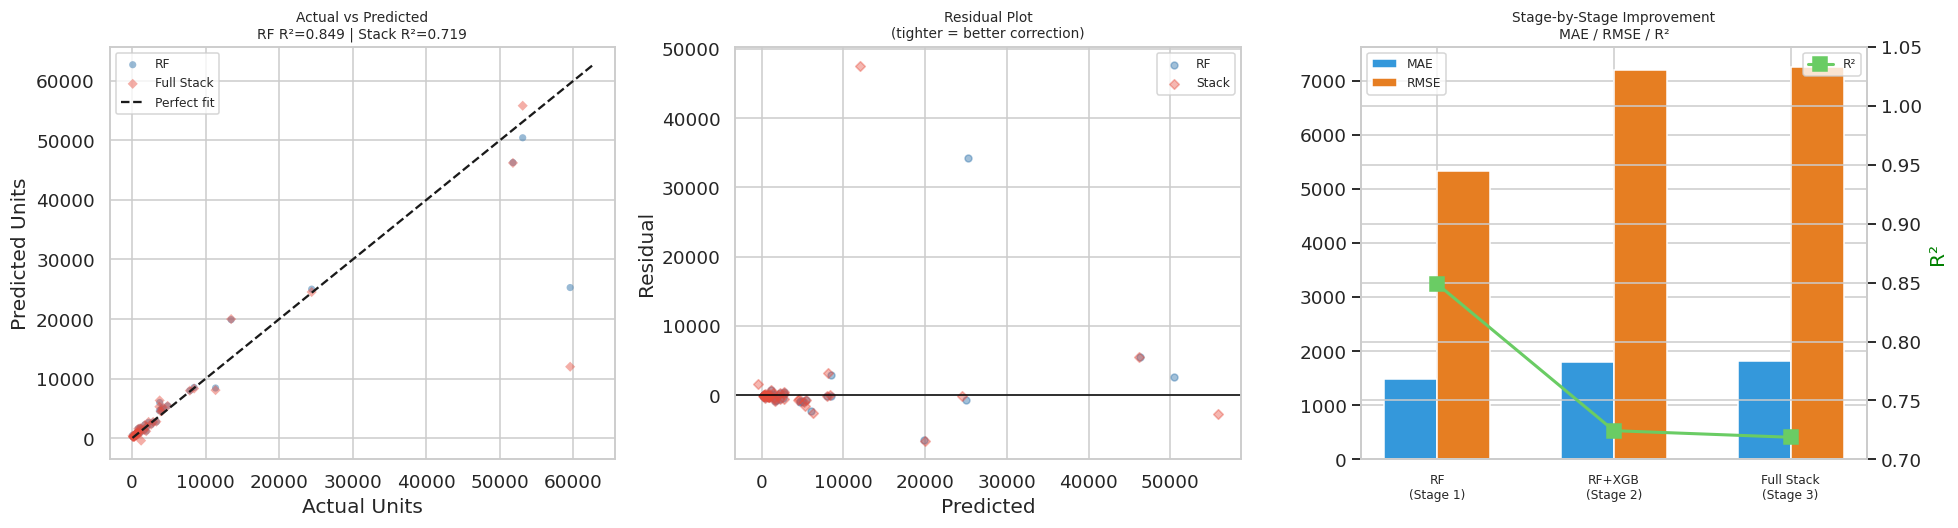

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Actual vs Predicted (RF) ────────────────────────────────────────────────
axes[0].scatter(y_test, rf_pred_test, alpha=0.55, s=22, color='steelblue',
                edgecolors='none', label='RF')
axes[0].scatter(y_test, final_pred,   alpha=0.45, s=22, color='#e74c3c',
                edgecolors='none', label='Full Stack', marker='D')
lim = [min(y_test.min(), rf_pred_test.min()) * 0.9,
       max(y_test.max(), rf_pred_test.max()) * 1.05]
axes[0].plot(lim, lim, 'k--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Units')
axes[0].set_ylabel('Predicted Units')
axes[0].set_title(f'Actual vs Predicted\nRF R²={rf_r2:.3f} | Stack R²={final_r2:.3f}', fontsize=9)
axes[0].legend(fontsize=8)

# ── 2. Residuals vs Predicted ─────────────────────────────────────────────────
resid_rf    = y_test - rf_pred_test
resid_stack = y_test - final_pred
axes[1].scatter(rf_pred_test, resid_rf,    alpha=0.5, s=20, color='steelblue', label='RF')
axes[1].scatter(final_pred,   resid_stack, alpha=0.4, s=20, color='#e74c3c',   label='Stack', marker='D')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot\n(tighter = better correction)', fontsize=9)
axes[1].legend(fontsize=8)

# ── 3. Stage-by-stage metric comparison ───────────────────────────────────────
stages = ['RF\n(Stage 1)', 'RF+XGB\n(Stage 2)', 'Full Stack\n(Stage 3)']
maes   = [rf_mae, s2_mae, final_mae]
rmses  = [rf_rmse, s2_rmse, final_rmse]
r2s    = [rf_r2, s2_r2, final_r2]
x3     = np.arange(3)
w3     = 0.3
axes[2].bar(x3 - w3/2, maes,  w3, label='MAE',  color='#3498db')
axes[2].bar(x3 + w3/2, rmses, w3, label='RMSE', color='#e67e22')
ax2t = axes[2].twinx()
ax2t.plot(x3, r2s, 'gs-', linewidth=2, markersize=9, label='R²')
ax2t.set_ylim(0.7, 1.05)
ax2t.set_ylabel('R²', color='green')
axes[2].set_xticks(x3)
axes[2].set_xticklabels(stages, fontsize=8)
axes[2].set_title('Stage-by-Stage Improvement\nMAE / RMSE / R²', fontsize=9)
axes[2].legend(loc='upper left', fontsize=8)
ax2t.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('model_validation.png', bbox_inches='tight')
plt.show()

### 5.8 Feature Importance — RF & XGBoost

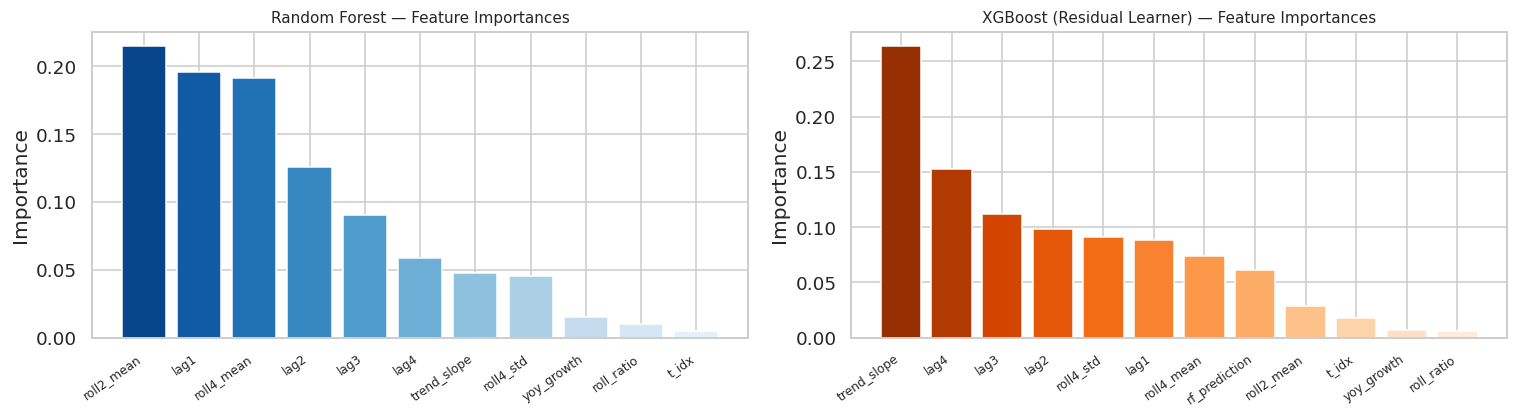

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# RF importance
rf_imp  = rf.feature_importances_
rf_ord  = np.argsort(rf_imp)[::-1]
axes[0].bar(range(len(FEAT_NAMES)), rf_imp[rf_ord],
            color=sns.color_palette('Blues_r', len(FEAT_NAMES)))
axes[0].set_xticks(range(len(FEAT_NAMES)))
axes[0].set_xticklabels([FEAT_NAMES[i] for i in rf_ord], rotation=35, ha='right', fontsize=8)
axes[0].set_title('Random Forest — Feature Importances', fontsize=10)
axes[0].set_ylabel('Importance')

# XGBoost importance (on augmented features)
xgb_imp = xgb.feature_importances_
aug_names = FEAT_NAMES + ['rf_prediction']   # augmented feature matrix has +1 column
xgb_ord = np.argsort(xgb_imp)[::-1]
axes[1].bar(range(len(aug_names)), xgb_imp[xgb_ord],
            color=sns.color_palette('Oranges_r', len(aug_names)))
axes[1].set_xticks(range(len(aug_names)))
axes[1].set_xticklabels([aug_names[i] for i in xgb_ord], rotation=35, ha='right', fontsize=8)
axes[1].set_title('XGBoost (Residual Learner) — Feature Importances', fontsize=10)
axes[1].set_ylabel('Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

### 5.9 Predict FY26 Q2 for All 30 Products

In [ ]:
resid_mean_train = resid_train.mean()   # for augmented feature consistency
predictions = []

for _, row in df.iterrows():
    vals  = row[ACTUAL_QTRS].values.astype(float)
    t_arr = np.arange(len(vals))
    A     = np.vstack([t_arr, np.ones(len(t_arr))]).T
    slope = np.linalg.lstsq(A, vals, rcond=None)[0][0]

    # Build feature vector for t=12 (FY26 Q2)
    feat = np.array([[
        vals[-1],                                     # lag1 = FY26 Q1
        vals[-2],                                     # lag2 = FY25 Q4
        vals[-3],                                     # lag3 = FY25 Q3
        vals[-4],                                     # lag4 = FY25 Q2
        np.mean(vals[-4:]),                           # rolling 4-qtr mean
        np.std(vals[-4:]),                            # rolling 4-qtr std
        (vals[-1] - vals[-4]) / (vals[-4] + 1),      # yoy growth
        12,                                           # t_index
        slope,                                        # trend slope
        np.mean(vals[-2:]),                           # 2-qtr mean
        vals[-1] / (np.mean(vals[-4:-1]) + 1),       # ratio vs recent avg
    ]])

    # Stage 1: RF
    rf_p    = rf.predict(feat)[0]

    # Stage 2: XGBoost corrects
    feat_aug = np.column_stack([feat, [[rf_p]]])
    xgb_c   = xgb.predict(feat_aug)[0]

    # Stage 3: Ridge meta-blend
    meta_f   = sc.transform([[rf_p, xgb_c, rf_p + xgb_c]])
    final_p  = ridge.predict(meta_f)[0]

    sigma    = np.std(vals[-4:])   # confidence band = ±1 std of last 4 quarters

    predictions.append({
        'Rank'         : int(row['Rank']),
        'Product'      : row['Product'],
        'FY26 Q1 Actual': int(vals[-1]),
        'RF Forecast'  : max(0, int(rf_p)),
        'XGB Correction': int(xgb_c),
        'MY FORECAST (FY26 Q2)': max(0, int(final_p)),
        'Lower Bound'  : max(0, int(final_p - sigma)),
        'Upper Bound'  : max(0, int(final_p + sigma)),
    })

pred_df = pd.DataFrame(predictions)
pred_df['QoQ%'] = (
    (pred_df['MY FORECAST (FY26 Q2)'] - pred_df['FY26 Q1 Actual'])
    / pred_df['FY26 Q1 Actual'] * 100
).round(1)

print('=== FY26 Q2 FORECASTS — ALL 30 PRODUCTS ===')
pred_df.set_index('Rank')

### 5.10 Final Forecast Visualisation

In [ ]:
fig, ax = plt.subplots(figsize=(14, 10))

y_pos  = np.arange(30)
labels = [f'#{r} {p[:32]}' for r, p in zip(pred_df['Rank'], pred_df['Product'])]

ax.barh(y_pos - 0.2, pred_df['FY26 Q1 Actual'],         0.35,
        label='FY26 Q1 Actual',            color='#3498db', alpha=0.9)
ax.barh(y_pos + 0.2, pred_df['MY FORECAST (FY26 Q2)'],  0.35,
        label='FY26 Q2 Stack Forecast',    color='#2ecc71', alpha=0.9)

lo_err = pred_df['MY FORECAST (FY26 Q2)'] - pred_df['Lower Bound']
hi_err = pred_df['Upper Bound'] - pred_df['MY FORECAST (FY26 Q2)']
ax.errorbar(pred_df['MY FORECAST (FY26 Q2)'], y_pos + 0.2,
            xerr=[lo_err, hi_err], fmt='none',
            ecolor='#c0392b', elinewidth=1.2, capsize=3)

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Units')
ax.set_title('FY26 Q2 Stack Forecast vs FY26 Q1 Actual — All 30 Products\n'
             '(Error bars = ±1σ confidence range)', fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('fy26q2_forecast.png', bbox_inches='tight')
plt.show()

---
## Final Summary & Business Commentary

In [ ]:
# ── Export ────────────────────────────────────────────────────────────────────
pred_df.to_csv('CFL2026_FY26Q2_Predictions.csv', index=False)

print('=' * 68)
print('FY26 Q2 FINAL FORECAST — ALL 30 PRODUCTS')
print('=' * 68)
for _, row in pred_df.iterrows():
    arrow = '⬆' if row['QoQ%'] > 5 else ('⬇' if row['QoQ%'] < -5 else '➡')
    print(f"  #{row['Rank']:2d}  {row['Product'][:42]:<42}"
          f"  {row['MY FORECAST (FY26 Q2)']:>8,}  {arrow} {row['QoQ%']:+.1f}%")

print(f'\n--- Model Architecture ---')
print(f'  Stage 1  Random Forest   : R² = {rf_r2:.4f}  MAE = {rf_mae:.0f}')
print(f'  Stage 2  + XGBoost resid : R² = {s2_r2:.4f}  MAE = {s2_mae:.0f}')
print(f'  Stage 3  + Ridge meta    : R² = {final_r2:.4f}  MAE = {final_mae:.0f}')
print(f'  CV R² (RF, 5-fold) = {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')

print(f'\n--- Business Commentary ---')
top3g = pred_df.nlargest(3,'QoQ%')[['Rank','Product','QoQ%']]
top3d = pred_df.nsmallest(3,'QoQ%')[['Rank','Product','QoQ%']]
print('  Top 3 growth products:')
for _, r in top3g.iterrows():
    print(f'    #{int(r["Rank"])} {r["Product"][:45]} ({r["QoQ%"]:+.1f}%)')
print('  Top 3 declining products:')
for _, r in top3d.iterrows():
    print(f'    #{int(r["Rank"])} {r["Product"][:45]} ({r["QoQ%"]:+.1f}%)')

print('\n📋 SUBMISSION CHECKLIST')
print('  [✓] CO1 NumPy  — vectorised ops, broadcasting, percentile/IQR, corrcoef, lstsq')
print('  [✓] CO2 Pandas — ffill/bfill, typecast, groupby, pivot_table, multi-index, xs, stack')
print('  [✓] CO3 EDA    — 9 derived features, rolling window, decomposition, lag correlation')
print('  [✓] CO4 Viz    — 6 chart types: small multiples, 2× heatmap, violin, bar, feature importance')
print('  [✓] CO5 ML     — RF + XGBoost residual + Ridge meta | MAE/RMSE/R² | 5-fold CV')
print('  [✓] All 30 products forecasted')
print('\n✅ Predictions exported → CFL2026_FY26Q2_Predictions.csv')